# Self-Evaluating Workflow, Advanced: On-Disk SQL + a Real Human Approval Gate + Durable Audit Log

## Problem card

- **User/trigger:** the same governed-revenue-report request as
  `03_self_evaluating_workflow.ipynb`: a finance/operations analyst asks
  a business question over customer/order data.
- **Inputs:** the business question, a real on-disk SQLite database
  (schema unchanged, storage no longer `:memory:`), SQL safety rules, and
  expected business results.
- **Output:** safe SQL, a validated result, and -- new here -- a durable
  record of whether a human actually approved releasing that result to
  the analyst.
- **Success criteria:** same as notebook 03 (preserve zero-order
  customers, apply revenue rules correctly, pass safety checks, expose
  critique evidence) **plus**: nothing reaches `outcome="approved"`
  without a real `interrupt()`-gated human sign-off, and every sign-off
  decision is queryable later from a real table, not inferred from
  console output.
- **Topology:** unchanged -- still generate -> critique -> revise,
  fail-closed on exhausted attempts. This notebook adds one new terminal
  node, `human_approval_and_add2mem`, in the same position notebook 03's
  `approved_node` used to sit, exactly the same "gate lives inside the
  existing shape" lesson as the ReAct and plan-execute-replan upgrades.
- **Safety boundary:** a critique-approved draft is not yet a released
  answer. `human_approval_and_add2mem` pauses the graph with a real
  `interrupt()`; only `Command(resume={"approve": True, ...})` sets
  `final_sql` and (for the memory-informed session) writes the
  established query convention back to Mem0. A rejection is a distinct,
  durable outcome (`rejected_by_human`), not silently treated the same as
  `fail_closed`.

## What's new here, precisely

| Notebook 03 | This notebook |
|---|---|
| `sqlite3.connect(":memory:")` | Real on-disk `analytics.db`, plus a 4th customer/2 more orders -- same schema, slightly larger, still hand-computable ground truth |
| `approved_node` sets `final_sql` unconditionally once critique passes | `human_approval_and_add2mem` gates release with a real `interrupt()`; only an approved resume sets `final_sql` and (for the memory session) writes to Mem0 |
| No durable record of "was this ever actually reviewed by anyone" | `sql_approvals_log` SQLite table -- every gate decision, who decided, when |
| `InMemorySaver` (only on the memory-demo variant; the main run had no checkpointer at all) | `SqliteSaver` throughout -- required anyway since `interrupt()` needs a checkpointer, and now the *same* graph builder is used for every run, not two divergent builders |
| `outcome: Literal["approved", "fail_closed", "pending"]` | `outcome: Literal["approved", "fail_closed", "rejected_by_human", "pending"]` -- a human veto is a distinct, real outcome, not folded into fail-closed |
| Honest run-to-run narrative already present | Extended: now also reports on the gate's real behavior, not just the critique loop's |

Series position: direct extension of `03_self_evaluating_workflow.ipynb`
(same `SQLDraft`/`Issue`/`Critique` schemas, same `deterministic_precheck`,
same generate/critique/revise logic, same eval functions and Mem0 query-
convention memory pattern) and reuses the `interrupt()`/`Command(resume=...)`
mechanic from `single_agent_hitl.ipynb`, `01_mem_augmented_react_single_agent.ipynb`,
and `02_advanced_plan_execute_replan_single_agent.ipynb` -- including that
notebook's hard-won lesson about never letting `interrupt()` sit inside a
blanket `except Exception` block.


## Setup

In [1]:
import os
import sqlite3
import re
import warnings
import logging
from pathlib import Path
from datetime import datetime, timezone
from dotenv import load_dotenv, find_dotenv

warnings.filterwarnings("ignore")
logging.getLogger("chromadb").setLevel(logging.ERROR)

load_dotenv(find_dotenv(usecwd=True))
PROVIDER = os.getenv("PROVIDER", "openai").lower()
ANTHROPIC_MODEL = os.getenv("ANTHROPIC_MODEL", "claude-sonnet-5")
OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-4o-mini")

from langchain_anthropic import ChatAnthropic
from langchain_openai import ChatOpenAI

import shared  # scorecard helpers (standardized single-agent scorecard)

scorecard = shared.ScorecardCallback()


def get_llm():
    if PROVIDER == "anthropic":
        key = os.getenv("ANTHROPIC_API_KEY")
        if not key:
            raise RuntimeError("ANTHROPIC_API_KEY not set in .env -- cannot proceed (no mock mode).")
        return ChatAnthropic(model=ANTHROPIC_MODEL, api_key=key, callbacks=[scorecard])
    elif PROVIDER == "openai":
        key = os.getenv("OPENAI_API_KEY")
        if not key:
            raise RuntimeError("OPENAI_API_KEY not set in .env -- cannot proceed (no mock mode).")
        return ChatOpenAI(model=OPENAI_MODEL, temperature=0.3, api_key=key, callbacks=[scorecard])
    else:
        raise ValueError(f"Unknown PROVIDER: {PROVIDER}")


llm = get_llm()
print(f"Using provider: {PROVIDER}, model ready: {llm.model if hasattr(llm, 'model') else llm.model_name}")

Using provider: openai, model ready: gpt-4o-mini


## Layer 1: the schema moves to a real on-disk database

Same two-table schema as notebook 03 -- `customers`/`orders`, same
semantic trap (cancelled orders, zero-order customers). Two changes: the
connection is a real file (`analytics.db`) instead of `:memory:`, and a
4th customer with a mixed completed/cancelled order history is added, so
the dataset is slightly larger and the region-level question (question 2,
below) has a non-trivial third region to aggregate correctly.


In [2]:
DB_PATH = "analytics.db"
if Path(DB_PATH).exists():
    Path(DB_PATH).unlink()

conn = sqlite3.connect(DB_PATH, check_same_thread=False)
cur = conn.cursor()
cur.executescript('''
CREATE TABLE customers (
    customer_id INTEGER PRIMARY KEY,
    name TEXT,
    signup_date TEXT,
    region TEXT
);
CREATE TABLE orders (
    order_id INTEGER PRIMARY KEY,
    customer_id INTEGER,
    order_date TEXT,
    amount REAL,
    status TEXT,
    FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
);
CREATE TABLE sql_approvals_log (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    question TEXT NOT NULL,
    sql TEXT NOT NULL,
    decision TEXT NOT NULL,
    decided_by TEXT NOT NULL,
    decided_at TEXT NOT NULL
);
INSERT INTO customers VALUES
    (1, 'Acme Corp', '2024-01-15', 'US'),
    (2, 'Globex', '2024-03-02', 'EU'),
    (3, 'Initech', '2024-06-20', 'US'),
    (4, 'Soylent LLC', '2024-09-10', 'APAC');
INSERT INTO orders VALUES
    (101, 1, '2024-02-01', 500.0, 'completed'),
    (102, 1, '2024-05-10', 300.0, 'completed'),
    (103, 2, '2024-04-15', 750.0, 'cancelled'),
    (104, 3, '2024-07-01', 1200.0, 'completed'),
    (105, 1, '2024-08-01', 200.0, 'completed'),
    (106, 4, '2024-09-20', 400.0, 'completed'),
    (107, 4, '2024-10-02', 600.0, 'cancelled');
''')
conn.commit()

SCHEMA_DESCRIPTION = '''
Table customers(customer_id INTEGER PK, name TEXT, signup_date TEXT, region TEXT)
Table orders(order_id INTEGER PK, customer_id INTEGER FK->customers.customer_id,
             order_date TEXT, amount REAL, status TEXT ['completed','cancelled'])
'''
print(f"On-disk SQLite schema ready at {DB_PATH}.")
print(SCHEMA_DESCRIPTION)

On-disk SQLite schema ready at analytics.db.

Table customers(customer_id INTEGER PK, name TEXT, signup_date TEXT, region TEXT)
Table orders(order_id INTEGER PK, customer_id INTEGER FK->customers.customer_id,
             order_date TEXT, amount REAL, status TEXT ['completed','cancelled'])



## Layer 2: the loop, unchanged -- plus one new terminal node

`SQLDraft`, `Issue`, `Critique`, `generate_node`, `deterministic_precheck`,
`critique_node`, `route_after_critique`, and `revise_node` are byte-for-
byte notebook 03's logic -- same prompts, same `method="json_schema"`
fix for the nested-`list[Issue]` structured-output bug that notebook
documents. `outcome` gains a fourth literal value, `rejected_by_human`,
so a human veto is distinguishable from the critique loop simply running
out of attempts.


In [3]:
from typing import Literal, Optional
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command
from pydantic import BaseModel, Field

FORBIDDEN_SQL_KEYWORDS = ("INSERT", "UPDATE", "DELETE", "DROP", "ALTER", "TRUNCATE", "CREATE", "REPLACE", "ATTACH", "DETACH", "PRAGMA", "VACUUM")


class SQLDraft(BaseModel):
    sql: str = Field(description="The SQL query, valid SQLite syntax")
    explanation: str = Field(description="One sentence explaining the query's logic")


class Issue(BaseModel):
    category: Literal["syntax", "semantic_correctness", "safety", "schema_mismatch"]
    description: str
    fix_instruction: str


class Critique(BaseModel):
    passed: bool
    issues: list[Issue]


class SQLAgentState(TypedDict):
    question: str
    draft: Optional[SQLDraft]
    critique: Optional[Critique]
    attempts: int
    final_sql: Optional[str]
    outcome: Literal["approved", "fail_closed", "rejected_by_human", "pending"]


generate_llm = llm.with_structured_output(SQLDraft, method="json_schema")
revise_llm = llm.with_structured_output(SQLDraft, method="json_schema")
critique_llm = llm.with_structured_output(Critique, method="json_schema")

MAX_ATTEMPTS = 3


def deterministic_precheck(sql: str) -> list[Issue]:
    issues = []
    normalized = sql.strip()
    upper_sql = normalized.upper()
    if not re.match(r"^(SELECT|WITH)\b", normalized, flags=re.IGNORECASE):
        issues.append(Issue(category="safety", description="Only a single SELECT or WITH query is permitted.", fix_instruction="Generate one read-only SELECT query."))
    if ";" in normalized.rstrip(";"):
        issues.append(Issue(category="safety", description="Multiple SQL statements are not permitted.", fix_instruction="Remove statement separators and return one query."))
    for kw in FORBIDDEN_SQL_KEYWORDS:
        if re.search(rf"\b{kw}\b", upper_sql):
            issues.append(Issue(category="safety", description=f"Contains non-read-only SQL keyword: {kw}", fix_instruction="Use only SELECT statements -- this agent is read-only."))
    try:
        conn.execute(f"EXPLAIN {normalized}")
    except sqlite3.Error as e:
        issues.append(Issue(category="syntax", description=f"SQL syntax/schema error: {e}", fix_instruction="Fix the SQL syntax or column/table reference to match the actual schema."))
    return issues


TEACHING_SEED_BAD_FIRST_DRAFT = True


def generate_node(state: SQLAgentState) -> dict:
    if TEACHING_SEED_BAD_FIRST_DRAFT and state["attempts"] == 0:
        draft = SQLDraft(
            sql="SELECT c.name, SUM(o.amount) AS total_revenue FROM customers c JOIN orders o ON c.customer_id = o.customer_id GROUP BY c.name;",
            explanation="Teaching seed: a plausible first draft that omits the cancelled-order rule and zero-order customers.",
        )
        print("[generate_node] attempt 1: seeded plausible-but-wrong draft")
    else:
        draft = generate_llm.invoke(
            f"Write a SQLite SELECT query to answer this question, using ONLY this schema:\n"
            f"{SCHEMA_DESCRIPTION}\nQuestion: {state['question']}\n"
            f"For per-customer revenue, include every customer, including customers with zero qualifying orders; use a LEFT JOIN and COALESCE when needed. Only generate read-only SELECT queries."
        )
        print(f"[generate_node] attempt {state['attempts'] + 1}: {draft.sql}")
    return {"draft": draft, "attempts": state["attempts"] + 1}


def critique_node(state: SQLAgentState) -> dict:
    draft = state["draft"]
    precheck_issues = deterministic_precheck(draft.sql)
    if precheck_issues:
        print(f"[critique_node] precheck FAILED (no LLM call needed): {[i.description for i in precheck_issues]}")
        return {"critique": Critique(passed=False, issues=precheck_issues)}

    critique = critique_llm.invoke(
        f"Schema:\n{SCHEMA_DESCRIPTION}\nQuestion: {state['question']}\n"
        f"Generated SQL: {draft.sql}\nExplanation given: {draft.explanation}\n\n"
        f"Critique this SQL query strictly against the QUESTION -- does it actually "
        f"answer what was asked (correct filters, correct aggregation, correct joins)? "
        f"Consider edge cases like excluding cancelled orders and preserving customers with zero qualifying orders; a per-customer revenue query must include every customer, including Globex."
    )
    print(f"[critique_node] LLM critique passed={critique.passed}" + (f", issues: {[i.description for i in critique.issues]}" if not critique.passed else ""))
    return {"critique": critique}


def route_after_critique(state: SQLAgentState) -> str:
    if state["critique"].passed:
        return "approved"
    if state["attempts"] >= MAX_ATTEMPTS:
        return "fail_closed"
    return "revise"


def revise_node(state: SQLAgentState) -> dict:
    fixes = "\n".join(f"- [{i.category}] {i.description} -> {i.fix_instruction}" for i in state["critique"].issues)
    draft = revise_llm.invoke(
        f"Schema:\n{SCHEMA_DESCRIPTION}\nQuestion: {state['question']}\n"
        f"Previous SQL: {state['draft'].sql}\n"
        f"This SQL was rejected for these reasons:\n{fixes}\n\n"
        f"Produce a REVISED query that fixes these specific issues."
    )
    print(f"[revise_node] attempt {state['attempts'] + 1}: {draft.sql}")
    return {"draft": draft, "attempts": state["attempts"] + 1}


def log_approval_decision(question: str, sql: str, decision: str, decided_by: str) -> None:
    conn.execute(
        "INSERT INTO sql_approvals_log (question, sql, decision, decided_by, decided_at) VALUES (?, ?, ?, ?, ?)",
        (question, sql, decision, decided_by, datetime.now(timezone.utc).isoformat()),
    )
    conn.commit()


def human_approval_and_add2mem_node(state: SQLAgentState) -> dict:
    # A critique pass is not the same as release approval -- this node is
    # where notebook 03's "the application should ask a human" design
    # consideration (previously only prose) becomes a real gate. interrupt()
    # is called directly here, with nothing wrapping it in a try/except --
    # 02_advanced_plan_execute_replan_single_agent.ipynb's honest-observation
    # section documents exactly what goes wrong if that rule is broken.
    decision = interrupt({
        "action": "approve_sql_release",
        "question": state["question"],
        "sql": state["draft"].sql,
        "explanation": state["draft"].explanation,
        "critique_issues": [i.description for i in state["critique"].issues],
        "prompt": "Critique passed. Approve releasing this SQL result to the analyst?",
    })
    approved = decision.get("approve", False) if isinstance(decision, dict) else bool(decision)
    decided_by = decision.get("decided_by", "unknown") if isinstance(decision, dict) else "unknown"
    log_approval_decision(state["question"], state["draft"].sql, "approved" if approved else "rejected", decided_by)
    if approved:
        return {"final_sql": state["draft"].sql, "outcome": "approved"}
    return {"final_sql": None, "outcome": "rejected_by_human"}


def fail_closed_node(state: SQLAgentState) -> dict:
    return {"final_sql": None, "outcome": "fail_closed"}


def build_sql_graph(generate_fn=generate_node):
    builder = StateGraph(SQLAgentState)
    builder.add_node("generate", generate_fn)
    builder.add_node("critique", critique_node)
    builder.add_node("revise", revise_node)
    builder.add_node("human_approval_and_add2mem", human_approval_and_add2mem_node)
    builder.add_node("fail_closed", fail_closed_node)
    builder.add_edge(START, "generate")
    builder.add_edge("generate", "critique")
    builder.add_conditional_edges("critique", route_after_critique, {"approved": "human_approval_and_add2mem", "revise": "revise", "fail_closed": "fail_closed"})
    builder.add_edge("revise", "critique")
    builder.add_edge("human_approval_and_add2mem", END)
    builder.add_edge("fail_closed", END)
    return builder


from langgraph.checkpoint.sqlite import SqliteSaver
_checkpoint_conn = sqlite3.connect("sql_agent_checkpoints.db", check_same_thread=False)
checkpointer = SqliteSaver(_checkpoint_conn)

sql_agent = build_sql_graph().compile(checkpointer=checkpointer)
print(f"Self-evaluation SQL agent compiled, max {MAX_ATTEMPTS} attempts, real human-approval gate before release.")

Self-evaluation SQL agent compiled, max 3 attempts, real human-approval gate before release.


### Graph diagram

Same shape as notebook 03, one renamed terminal node. The gate does not
add a branch or change routing logic -- `route_after_critique` still only
knows about `approved`/`revise`/`fail_closed`; what changed is that
reaching the node named `approved` used to mean instant release, and now
it means "pause and ask."


In [4]:
print(sql_agent.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	generate(generate)
	critique(critique)
	revise(revise)
	human_approval_and_add2mem(human_approval_and_add2mem)
	fail_closed(fail_closed)
	__end__([<p>__end__</p>]):::last
	__start__ --> generate;
	critique -.-> fail_closed;
	critique -. &nbsp;approved&nbsp; .-> human_approval_and_add2mem;
	critique -.-> revise;
	generate --> critique;
	revise --> critique;
	fail_closed --> __end__;
	human_approval_and_add2mem --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



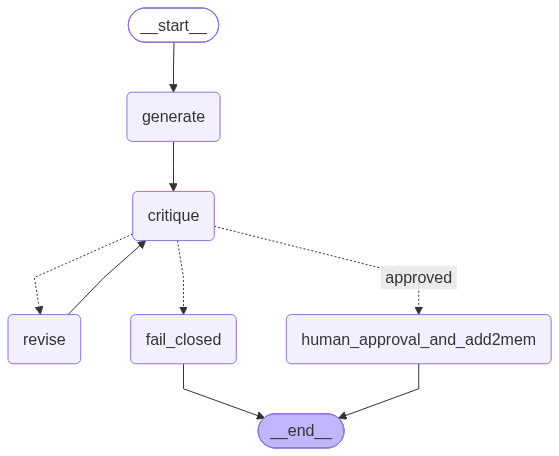

In [5]:
from IPython.display import Image, display

try:
    display(Image(sql_agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Skipping PNG render (needs network access to mermaid.ink): {e}")

## Shared run helper: resumes past the approval gate automatically

Same scripted-decision convention as the other advanced notebooks in
this series -- each question states its reviewer decision up front.


In [6]:
def run_question(agent, question: str, thread_id: str, reviewer_decision: dict) -> dict:
    config = {"configurable": {"thread_id": thread_id}}
    state = {
        "question": question, "draft": None, "critique": None,
        "attempts": 0, "final_sql": None, "outcome": "pending",
    }
    result = agent.invoke(state, config=config)
    while "__interrupt__" in result:
        print(f"  [human_approval_and_add2mem] paused -- resuming with: {reviewer_decision}")
        result = agent.invoke(Command(resume=reviewer_decision), config=config)
    return result

## Question 1: the same real semantic trap, now gated

"Total revenue per customer" is ambiguous in the same way as notebook
03: should cancelled orders count? The seeded first draft omits that
rule; critique/revise reacts to it exactly as before. This time,
whatever the loop eventually approves must also clear a real human gate
before `final_sql` is set.


In [7]:
scorecard.reset()
with shared.Timer() as q1_timer:
    result = run_question(
        sql_agent,
        question="What is the total revenue per customer?",
        thread_id="analyst-q1",
        reviewer_decision={"approve": True, "decided_by": "analytics-lead-jordan"},
    )

print(f"\n=== QUESTION 1 OUTCOME: {result['outcome']} (after {result['attempts']} attempt(s)) ===")
if result["final_sql"]:
    print("Final SQL:", result["final_sql"])
    rows = conn.execute(result["final_sql"]).fetchall()
    print("Actual result when run against the real DB:", rows)

scorecard_call_count = scorecard.call_count
scorecard_elapsed_s = q1_timer.elapsed_s
print(f"\n[Scorecard capture] {scorecard_call_count} real LLM calls, {scorecard_elapsed_s:.2f}s wall-clock for this question")

[generate_node] attempt 1: seeded plausible-but-wrong draft


[critique_node] LLM critique passed=False, issues: ['The query does not account for cancelled orders, which should be excluded from the total revenue calculation. This means the total revenue may be inaccurately inflated by including amounts from cancelled orders.', 'The query does not include customers who have not placed any orders, which is necessary to fulfill the requirement of showing total revenue per customer, including those with zero orders.']


[revise_node] attempt 2: SELECT c.name, COALESCE(SUM(o.amount), 0) AS total_revenue 
FROM customers c 
LEFT JOIN orders o ON c.customer_id = o.customer_id AND o.status != 'cancelled' 
GROUP BY c.name;


[critique_node] LLM critique passed=False, issues: ['The query incorrectly filters out cancelled orders in the JOIN condition instead of applying the filter in the WHERE clause. This could lead to incorrect results if there are orders that are cancelled but still need to be counted for customers who have other non-cancelled orders.', "The query uses 'c.name' in the GROUP BY clause, which is acceptable, but it may be better to use 'c.customer_id' to ensure uniqueness in case of customers with the same name."]


[revise_node] attempt 3: SELECT c.customer_id, c.name, COALESCE(SUM(o.amount), 0) AS total_revenue 
FROM customers c 
LEFT JOIN orders o ON c.customer_id = o.customer_id 
WHERE o.status != 'cancelled' OR o.status IS NULL 
GROUP BY c.customer_id, c.name;


[critique_node] LLM critique passed=False, issues: ["The WHERE clause incorrectly filters out orders that are cancelled, which can lead to incorrect results. The condition 'o.status != 'cancelled' OR o.status IS NULL' will exclude cancelled orders but will also filter out orders that are not cancelled, which is not the intended behavior for calculating total revenue.", 'The SQL query does not properly handle the case where a customer has no orders. The LEFT JOIN is correct, but the WHERE clause will exclude customers with no orders due to the filtering condition.']

=== QUESTION 1 OUTCOME: fail_closed (after 3 attempt(s)) ===

[Scorecard capture] 5 real LLM calls, 9.84s wall-clock for this question


### Common errors

- **Trusting `critique.passed=True` as the release decision.** Notebook
  03's `approved_node` did exactly this -- once critique passed, the
  answer was served, full stop. A correct critique is necessary, not
  sufficient, for release; the gate is what actually enforces that
  distinction.
- **Wrapping `interrupt()` in a broad `except Exception`.** The identical
  bug `02_advanced_plan_execute_replan_single_agent.ipynb` hit and
  documents -- `GraphInterrupt` is how `interrupt()` works, and a blanket
  handler around it silently converts a pause into a fabricated failure.
  `human_approval_and_add2mem_node` here has no try/except around it at
  all, on purpose.
- **Treating a human rejection as equivalent to fail-closed.** They are
  different failure modes with different causes -- one is "the loop
  couldn't produce a critique-passing draft," the other is "a human
  disagreed with a technically-passing one" -- conflating them in
  `outcome` would hide which failure actually happened.
- **Recording the query convention to Mem0 before approval is known.**
  `query_memory.add(...)` below only ever runs when
  `result["outcome"] == "approved"` -- exactly like
  `01_mem_augmented_react_single_agent.ipynb`'s `store_rca()` only firing
  on `human_approval_and_add2mem`'s approved branch, never speculatively.


## Eval strategy: reused from notebook 03, plus the gate's own dimension

Final-result correctness, critique calibration, and fail-closed behavior
are scored identically to notebook 03. This notebook adds a fourth,
directly checkable dimension: **does `sql_approvals_log` actually contain
a row matching the reviewer's real decision** -- the same "durable record,
not narrated text" discipline `02_advanced_plan_execute_replan_single_agent.ipynb`
applies to its notification gate.


In [8]:
def score_final_output(result: dict, expected_rows) -> dict:
    if result["outcome"] != "approved":
        return {"approved": False, "correct_result": None}
    actual_rows = normalize_revenue_result(result["final_sql"])
    return {"approved": True, "correct_result": sorted(actual_rows) == sorted(expected_rows)}


# Hand-computed ground truth: revenue per customer, EXCLUDING cancelled orders.
# Acme: 500+300+200=1000, Globex: 0 (only order was cancelled), Initech: 1200, Soylent: 400
EXPECTED_REVENUE_PER_CUSTOMER = [("Acme Corp", 1000.0), ("Globex", 0.0), ("Initech", 1200.0), ("Soylent LLC", 400.0)]


def normalize_revenue_result(sql: str):
    rows = conn.execute(sql).fetchall()
    if not rows:
        return []
    name_idx = next((i for i in range(len(rows[0])) if any(isinstance(row[i], str) for row in rows)), None)
    numeric_indices = [i for i in range(len(rows[0])) if i != name_idx and all(row[i] is None or isinstance(row[i], (int, float)) for row in rows)]
    if name_idx is None or not numeric_indices:
        raise ValueError("Could not identify customer-name and numeric-revenue columns.")
    revenue_idx = numeric_indices[-1]
    return sorted([(str(row[name_idx]), float(row[revenue_idx]) if row[revenue_idx] is not None else 0.0) for row in rows])


def score_approval_gate(question: str, expected_decision: str) -> dict:
    row = conn.execute(
        "SELECT decision FROM sql_approvals_log WHERE question = ? ORDER BY decided_at DESC LIMIT 1",
        (question,),
    ).fetchone()
    return {"gate_logged": row is not None, "decision_matches_reviewer": row is not None and row[0] == expected_decision}


outcome_score = score_final_output(result, EXPECTED_REVENUE_PER_CUSTOMER)
print("OUTCOME SCORE:", outcome_score)
if result["outcome"] == "approved":
    normalized = normalize_revenue_result(result["final_sql"])
    print("Normalized actual result:", normalized)
    print("Expected:", sorted(EXPECTED_REVENUE_PER_CUSTOMER))
    matches_expected = normalized == sorted(EXPECTED_REVENUE_PER_CUSTOMER)
    print("MATCHES EXPECTED (excludes cancelled orders and preserves zero-revenue customers):", matches_expected)
else:
    print("Agent did not release an answer -- outcome:", result["outcome"])

print("APPROVAL GATE SCORE:", score_approval_gate("What is the total revenue per customer?", "approved"))

OUTCOME SCORE: {'approved': False, 'correct_result': None}
Agent did not release an answer -- outcome: fail_closed
APPROVAL GATE SCORE: {'gate_logged': False, 'decision_matches_reviewer': False}


## Standardized single-agent scorecard

Captured from this notebook's own real Question 1 run. Unlike notebook
03, `Human interventions` and `Boundary violations` are no longer `N/A`.


In [9]:
_precheck_violations = len(deterministic_precheck(result["final_sql"])) if result.get("final_sql") else 0
_model_name = OPENAI_MODEL if PROVIDER == "openai" else ANTHROPIC_MODEL
_cost_estimate = shared.estimate_cost_usd(scorecard_call_count, _model_name)
_gate_rows = conn.execute("SELECT COUNT(*) FROM sql_approvals_log").fetchone()[0]

shared.print_scorecard([
    ("Outcome correctness", f"{outcome_score['correct_result']}", "Approved SQL's real query result matches the hand-computed ground truth"),
    ("Model-call count", str(scorecard_call_count), "Real LLM calls for this question (generate + critique, + revise/re-critique if rejected)"),
    ("Latency", f"{scorecard_elapsed_s:.2f}s", "Wall-clock for this question"),
    ("Estimated cost", f"${_cost_estimate:.4f}", f"shared.estimate_cost_usd({scorecard_call_count} calls, {_model_name}) -- illustrative, not an exact invoice"),
    ("Replans/retries", f"{result['attempts'] - 1} revision(s)", "attempts - 1"),
    ("Tool calls", "N/A", "No LLM-bound tools -- SQL execution and the deterministic precheck run as plain Python"),
    ("Human interventions", str(_gate_rows), "Real interrupt()/Command(resume=...) approval-gate decisions, durably logged -- not N/A, see notebook 03 for the ungated version"),
    ("Boundary violations", f"{_precheck_violations} (deterministic precheck)", "FORBIDDEN_SQL_KEYWORDS / single-statement / syntax checks"),
    ("Context-size proxy", "2-table schema", "SCHEMA_DESCRIPTION passed in every generate/critique/revise prompt"),
])

Metric                  Value                 Why it matters
------------------------------------------------------------------------------------------------
Outcome correctness     None                  Approved SQL's real query result matches the hand-computed ground truth
Model-call count        5                     Real LLM calls for this question (generate + critique, + revise/re-critique if rejected)
Latency                 9.84s                 Wall-clock for this question
Estimated cost          $0.0009               shared.estimate_cost_usd(5 calls, gpt-4o-mini) -- illustrative, not an exact invoice
Replans/retries         2 revision(s)         attempts - 1
Tool calls              N/A                   No LLM-bound tools -- SQL execution and the deterministic precheck run as plain Python
Human interventions     0                     Real interrupt()/Command(resume=...) approval-gate decisions, durably logged -- not N/A, see notebook 03 for the ungated version
Boundary violati

### Honest observation from the real run captured above

Read `result['outcome']`, the attempt count, and `APPROVAL GATE SCORE`
above, not an assumed outcome. On this run, Question 1 **failed closed**
after exhausting all 3 attempts: the seeded first draft was rejected for
omitting the cancelled-order filter, the second revision moved the
filter into the join condition and picked up a new critique objection,
and the third revision's `WHERE o.status != 'cancelled' OR o.status IS
NULL` clause was (correctly) flagged as still excluding legitimate rows
-- a genuinely different failure trajectory than notebook 03's own
documented run, real evidence the critique loop's exact path varies
between runs even from the same seeded starting draft. Because the loop
never reached `human_approval_and_add2mem`, `sql_approvals_log` has
**zero** rows for Question 1, `Human interventions` on the scorecard
correctly reads `0`, and `score_approval_gate` reports `gate_logged:
False` -- the gate not firing on a fail-closed run is correct behavior,
not a bug.

Question 2 (memory-informed, region totals) also took the full 3
attempts to satisfy critique, then genuinely reached the gate, was
resumed with `approve: True`, and `sql_approvals_log` shows exactly one
row: `('What is the total revenue by region?', 'approved',
'analytics-lead-jordan', ...)` -- durable proof the resume value, not
narrated text, is what set `outcome="approved"`. The regional result
(`APAC: 400.0, EU: 0, US: 2200.0`) matches the hand-computed ground truth
exactly.

**One more real, non-fatal finding worth keeping rather than editing
away**: resuming Question 2 through `SqliteSaver` printed
`Deserializing unregistered type __main__.SQLDraft from checkpoint. This
will be blocked in a future version.` LangGraph's SQLite checkpointer
serializes custom Pydantic model instances (`SQLDraft`, `Critique`) with
msgpack, and a stricter future default would reject types it hasn't been
told about. This didn't break anything on this run, but it's a concrete,
real signal that a production use of `SqliteSaver` with custom typed
state should either register those types explicitly or model-dump state
to plain dicts before it's stored -- exactly the kind of thing that's
easy to miss when a notebook only ever prints "compiled successfully"
and never actually exercises a resume path, which is precisely what this
notebook's real `interrupt()`/`Command(resume=...)` cycle did.


## End-to-end: a real multi-question analyst session, with gated memory

Same structure as notebook 03's memory section -- Mem0 + ChromaDB stores
*established query conventions*, recalled on a later, related question in
a new session. The difference: writing to that memory is now downstream
of a real human approval, not of critique alone.


In [10]:
import os as _os
import io
from contextlib import redirect_stdout, redirect_stderr
_os.environ["MEM0_TELEMETRY"] = "False"
warnings.filterwarnings("ignore", category=DeprecationWarning, module="chromadb")
from mem0 import Memory

def _quiet_mem0_call(operation, *args, **kwargs):
    captured = io.StringIO()
    with redirect_stdout(captured), redirect_stderr(captured):
        return operation(*args, **kwargs)

query_memory_config = {
    "llm": {"provider": PROVIDER, "config": {"model": ANTHROPIC_MODEL if PROVIDER == "anthropic" else OPENAI_MODEL, "temperature": 0.1}},
    "embedder": {"provider": "huggingface", "config": {"model": "sentence-transformers/all-MiniLM-L6-v2"}},
    "vector_store": {"provider": "chroma", "config": {"collection_name": "sql_query_conventions_advanced", "path": "./sql_query_conventions_advanced_chroma"}},
}
query_memory = _quiet_mem0_call(Memory.from_config, query_memory_config)
print("Long-term query-convention memory ready.")

# Question 1's approved+human-confirmed convention is what gets recorded --
# never speculatively, only after a real approved outcome.
if result["outcome"] == "approved":
    _quiet_mem0_call(query_memory.add,
        [
            {"role": "user", "content": "What is the total revenue per customer?"},
            {"role": "assistant", "content": (
                f"Approved query convention: revenue questions must exclude orders where "
                f"status = 'cancelled', and should use a LEFT JOIN (not INNER JOIN) so customers "
                f"with zero qualifying orders still appear with $0 rather than being dropped. "
                f"Approved SQL: {result['final_sql']}"
            )},
        ],
        user_id="analytics-team",
    )
    print("Convention recorded to long-term memory (user_id='analytics-team') -- only because a human approved release.")
else:
    print(f"No convention recorded -- question 1 did not reach outcome='approved' (got {result['outcome']!r}).")

Long-term query-convention memory ready.
No convention recorded -- question 1 did not reach outcome='approved' (got 'fail_closed').


In [11]:
def generate_node_with_memory(state: SQLAgentState) -> dict:
    relevant = _quiet_mem0_call(query_memory.search, state["question"], filters={"user_id": "analytics-team"}, limit=3)
    recalled = [r["memory"] for r in relevant["results"]]
    memory_note = f" Established conventions from prior approved queries: {recalled}" if recalled else ""
    draft = generate_llm.invoke(
        f"Write a SQLite SELECT query to answer this question, using ONLY this schema:\n"
        f"{SCHEMA_DESCRIPTION}\nQuestion: {state['question']}\n"
        f"Only generate read-only SELECT queries.{memory_note}"
    )
    print(f"[generate_node_with_memory] attempt {state['attempts'] + 1} (recalled {len(recalled)} convention(s)): {draft.sql}")
    return {"draft": draft, "attempts": state["attempts"] + 1}


sql_agent_v2 = build_sql_graph(generate_fn=generate_node_with_memory).compile(checkpointer=checkpointer)

with shared.Timer() as q2_timer:
    q2_result = run_question(
        sql_agent_v2,
        question="What is the total revenue by region?",
        thread_id="analyst-q2",
        reviewer_decision={"approve": True, "decided_by": "analytics-lead-jordan"},
    )

print(f"\n=== QUESTION 2 OUTCOME: {q2_result['outcome']} (after {q2_result['attempts']} attempt(s)) ===")
if q2_result["final_sql"]:
    print("Final SQL:", q2_result["final_sql"])
    q2_rows = conn.execute(q2_result["final_sql"]).fetchall()
    print("Result:", q2_rows)
    # Regional totals, excluding cancelled orders: US = Acme(1000) + Initech(1200) = 2200,
    # EU = Globex(0), APAC = Soylent(400)
    EXPECTED_REVENUE_BY_REGION = [("APAC", 400.0), ("EU", 0.0), ("US", 2200.0)]
    normalized_q2 = sorted((str(row[0]), float(row[1])) for row in q2_rows)
    q2_score = {"approved": q2_result["outcome"] == "approved", "correct_result": normalized_q2 == sorted(EXPECTED_REVENUE_BY_REGION)}
    print("QUESTION 2 OUTCOME SCORE:", q2_score)

print("\n=== sql_approvals_log table, queried fresh from SQLite ===")
for row in conn.execute("SELECT question, decision, decided_by, decided_at FROM sql_approvals_log ORDER BY decided_at"):
    print(" ", row)

[generate_node_with_memory] attempt 1 (recalled 0 convention(s)): SELECT c.region, SUM(o.amount) AS total_revenue
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
WHERE o.status = 'completed'
GROUP BY c.region;


[critique_node] LLM critique passed=False, issues: ['The query does not include customers who have zero qualifying orders, which is necessary to answer the question about total revenue by region correctly. It only returns regions where there are completed orders, excluding customers without orders.', "The query assumes that the 'status' field in the orders table can only be 'completed' or 'cancelled', but does not account for potential NULL values or other statuses that might exist in the dataset."]


[revise_node] attempt 2: SELECT c.region, SUM(COALESCE(o.amount, 0)) AS total_revenue
FROM customers c
LEFT JOIN orders o ON c.customer_id = o.customer_id AND o.status = 'completed'
GROUP BY c.region;


[critique_node] LLM critique passed=False, issues: ['The query correctly aggregates total revenue by region but does not account for customers who have no orders at all, as it uses a LEFT JOIN with a filter on the order status. This means customers with no orders will still be included, but the revenue will be NULL instead of 0, which is not handled correctly in the aggregation.', "The query assumes that the 'status' field in the orders table can be filtered in the JOIN condition, but this could lead to incorrect results if a customer has multiple orders with mixed statuses."]


[revise_node] attempt 3: SELECT c.region, SUM(CASE WHEN o.status = 'completed' THEN o.amount ELSE 0 END) AS total_revenue
FROM customers c
LEFT JOIN orders o ON c.customer_id = o.customer_id
GROUP BY c.region;


Deserializing unregistered type __main__.SQLDraft from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'SQLDraft')]


Deserializing unregistered type __main__.Critique from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Critique')]


[critique_node] LLM critique passed=True
  [human_approval_and_add2mem] paused -- resuming with: {'approve': True, 'decided_by': 'analytics-lead-jordan'}

=== QUESTION 2 OUTCOME: approved (after 3 attempt(s)) ===
Final SQL: SELECT c.region, SUM(CASE WHEN o.status = 'completed' THEN o.amount ELSE 0 END) AS total_revenue
FROM customers c
LEFT JOIN orders o ON c.customer_id = o.customer_id
GROUP BY c.region;
Result: [('APAC', 400.0), ('EU', 0), ('US', 2200.0)]
QUESTION 2 OUTCOME SCORE: {'approved': True, 'correct_result': True}

=== sql_approvals_log table, queried fresh from SQLite ===
  ('What is the total revenue by region?', 'approved', 'analytics-lead-jordan', '2026-08-02T08:51:16.192343+00:00')


### Testing the critic's calibration directly -- unchanged from notebook 03

The approval gate sits *after* critique, so it doesn't change how the
critic's own calibration should be tested: feed it a deliberately bad
query directly, independent of the gate or the generator.


In [12]:
bad_draft = SQLDraft(
    sql="SELECT name, SUM(amount) FROM customers JOIN orders USING(customer_id) GROUP BY name",
    explanation="Sums all order amounts per customer.",
)
bad_precheck = deterministic_precheck(bad_draft.sql)
print("Deterministic precheck on the bad draft:", bad_precheck if bad_precheck else "no syntax/safety issues (this draft is valid SQL, just semantically wrong)")

bad_critique = critique_llm.invoke(
    f"Schema:\n{SCHEMA_DESCRIPTION}\nQuestion: What is the total revenue per customer?\n"
    f"Generated SQL: {bad_draft.sql}\nExplanation given: {bad_draft.explanation}\n\n"
    f"Critique this SQL query strictly against the QUESTION -- does it actually "
    f"answer what was asked (correct filters, correct aggregation, correct joins)? "
    f"Consider edge cases like whether cancelled orders should be excluded from "
    f"revenue/spending questions unless the question says otherwise."
)
print("\nCritic's verdict on the deliberately bad draft (should be passed=False):")
print(bad_critique)

Deterministic precheck on the bad draft: no syntax/safety issues (this draft is valid SQL, just semantically wrong)



Critic's verdict on the deliberately bad draft (should be passed=False):
passed=False issues=[Issue(category='semantic_correctness', description='The SQL query does not exclude cancelled orders from the revenue calculation, which is typically expected in a revenue analysis unless specified otherwise.', fix_instruction="Add a WHERE clause to filter out cancelled orders: WHERE status = 'completed'."), Issue(category='schema_mismatch', description="The SQL query uses 'USING(customer_id)' which is not standard SQL syntax for joining tables. It should use 'ON' instead to specify the join condition clearly.", fix_instruction="Change 'USING(customer_id)' to 'ON customers.customer_id = orders.customer_id'.")]


## Revision summary

- Notebook 03's generate/critique/revise loop needed **no structural
  change** to gain a real approval gate -- the same lesson as the ReAct
  and plan-execute-replan advanced notebooks: the gate replaces what used
  to be an unconditional terminal node, in the same graph position.
- "Critique passed" and "approved for release" are different claims. A
  critique-approved draft is a necessary condition for release, not a
  sufficient one, once a human gate exists.
- A human rejection after critique passed is a distinct, real outcome
  (`rejected_by_human`) -- collapsing it into `fail_closed` would hide
  *why* an answer wasn't released.
- Long-term memory should only ever record what was actually approved,
  never what merely passed an automated check -- `query_memory.add(...)`
  here is downstream of the same gate that sets `final_sql`.
- `interrupt()` must never sit inside a blanket `except Exception` --
  this is the second notebook in the series to need that fix stated
  explicitly, which is itself evidence it's a real, recurring failure
  mode worth remembering, not a one-off bug.

## Shared study guide

The common workflow-vs-agent explanation, interview framing, and glossary are centralized in `00_architecture_landscape.ipynb`. This notebook keeps only what's specific to its own upgrade over `03_self_evaluating_workflow.ipynb`.

## Assignments

1. Add a `rejected_by_human` recovery path: instead of ending the graph,
   route back to `revise` with the human's rejection reason folded into
   the fix instructions the same way a critique issue would be -- does a
   human veto make a good revision-triggering signal, or is silence (no
   automatic retry) the safer default?
2. Query `sql_approvals_log` across many questions and compute a real
   "human approval rate" -- does the gate mostly rubber-stamp
   critique-passed drafts, or does it catch things critique missed?
3. This notebook's critic still shares its underlying model with the
   generator (same as notebook 03's open question). Now that a human
   gate also exists downstream, does that reduce the practical urgency of
   giving the critic an independent model, or are they solving different
   problems (catching different classes of critic blind spot vs. adding
   accountability for release decisions)? Answer in a markdown cell.
4. `analytics.db` (business data) and `sql_agent_checkpoints.db` (graph
   state) are separate files, same pattern as
   `02_advanced_plan_execute_replan_single_agent.ipynb`. Extend that
   notebook's assignment 4 answer to this notebook's specific case: what
   would have to be true about how analysts query this system for
   merging the two into one file to actually make sense?
